# SPS MBB Dipole -- 2 Hz Campaign: Presentation Figures

**Campaign:** 2026-02-25, 2 Hz (120 RPM), two coil segments (body + fringe)

All data loaded from pre-computed CSVs produced by `200GeV_analysis.ipynb`,
`26GeV_analysis.ipynb`, and `integrated_field.ipynb`.

| # | Section |
|---|--------|
| 1 | Data loading |
| 2 | Current cycle with turn classification |
| 3 | Eddy-current settling: 200 GeV MD1 and 26 GeV MD1 |
| 4 | Eddy-current fit summary and physics |
| 5 | Dipole field B$_1$ summary |
| 6 | Harmonic spectra: body + fringe (linear + log) and integrated |

---
## 1. Data Loading

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib widget
plt.rcParams.update({
    'figure.figsize': (14, 5), 'axes.grid': True, 'grid.alpha': 0.3,
    'figure.dpi': 120, 'font.size': 11,
})

REPO = Path('.').resolve()
while REPO != REPO.parent:
    if (REPO / '.git').exists(): break
    REPO = REPO.parent
OUT = REPO / 'output' / 'MBB' / '2026-02-25_2Hz'

# Output folder for presentation exports
PLOT_DIR = Path('.').resolve() / 'presentation_export'
PLOT_DIR.mkdir(exist_ok=True)

ENERGIES = ['200GeV', '26GeV']
EN_DISP = {'200GeV': '200 GeV MD1', '26GeV': '26 GeV MD1'}
EN_SLUG = {'200GeV': '200GeV_MD1', '26GeV': '26GeV_MD1'}
SEGS = ['CS', 'NCS']
HARMONICS = list(range(2, 16))

# --- Load everything ---
plateau, eddy_inj, settled, fits_mean = {}, {}, {}, {}
fits_per_sc = {}  # (energy, seg, qty)

for en in ENERGIES:
    d = OUT / en
    fits_mean[en] = pd.read_csv(d / 'eddy_fits_mean.csv')
    for seg in SEGS:
        plateau[(en, seg)] = pd.read_csv(d / f'MBB_{seg}_streaming_plateau.csv')
        eddy_inj[(en, seg)] = pd.read_csv(d / f'eddy_injection_{seg}.csv')
        settled[(en, seg)] = pd.read_csv(d / f'MBB_{seg}_streaming_settled.csv')
        for qty in ['B1', 'b2', 'b3']:
            fits_per_sc[(en, seg, qty)] = pd.read_csv(d / f'eddy_fits_{qty}_{seg}.csv')

int_harmonics = pd.read_csv(OUT / 'integrated_field' / 'integrated_harmonics.csv')

# Auto-detect body/fringe from TF
tf = {seg: settled[('200GeV', seg)].query('label=="injection"')['TF_TperkA'].abs().mean()
      for seg in SEGS}
BODY = max(tf, key=tf.get)
FRINGE = min(tf, key=tf.get)
DISP = {BODY: 'Body', FRINGE: 'Fringe'}

print(f'Body segment:   |TF| = {tf[BODY]:.4f} T/kA')
print(f'Fringe segment: |TF| = {tf[FRINGE]:.4f} T/kA')
for en in ENERGIES:
    for seg in [BODY, FRINGE]:
        n = eddy_inj[(en, seg)]['sc_idx'].nunique()
        print(f'  {EN_DISP[en]} {DISP[seg]}: {len(eddy_inj[(en,seg)])} inj turns, {n} SCs')
print(f'\nPlots will be saved to: {PLOT_DIR}')

Body segment:   |TF| = 0.3864 T/kA
Fringe segment: |TF| = 0.0652 T/kA
  200 GeV MD1 Body: 1015 inj turns, 36 SCs
  200 GeV MD1 Fringe: 1015 inj turns, 36 SCs
  26 GeV MD1 Body: 1079 inj turns, 36 SCs
  26 GeV MD1 Fringe: 1079 inj turns, 36 SCs

Plots will be saved to: C:\Users\albellel\python-projects\rotating-coil-analyzer\rotating_coil_analyzer\notebooks\SPS_MBB\2026-02-25_2Hz\presentation_export


---
## 2. Current Cycle with Turn Classification

The SPS supercycle ramps the magnet current from ~300 A (injection) to ~4800 A
(flat-top) and back. The rotating coil measures continuously at 2 Hz.

Only turns sitting entirely on a **current plateau** (dI/dt $\approx$ 0) are
usable for precision field measurement. During ramps the field changes within
one rotation, mixing eddy currents with the quasi-static field.

- **Green:** injection plateau (~300 A) -- used for eddy settling + low-field harmonics
- **Blue:** flat-top plateau (~4800 A) -- used for high-field harmonics
- **Red:** ramp turns -- rejected

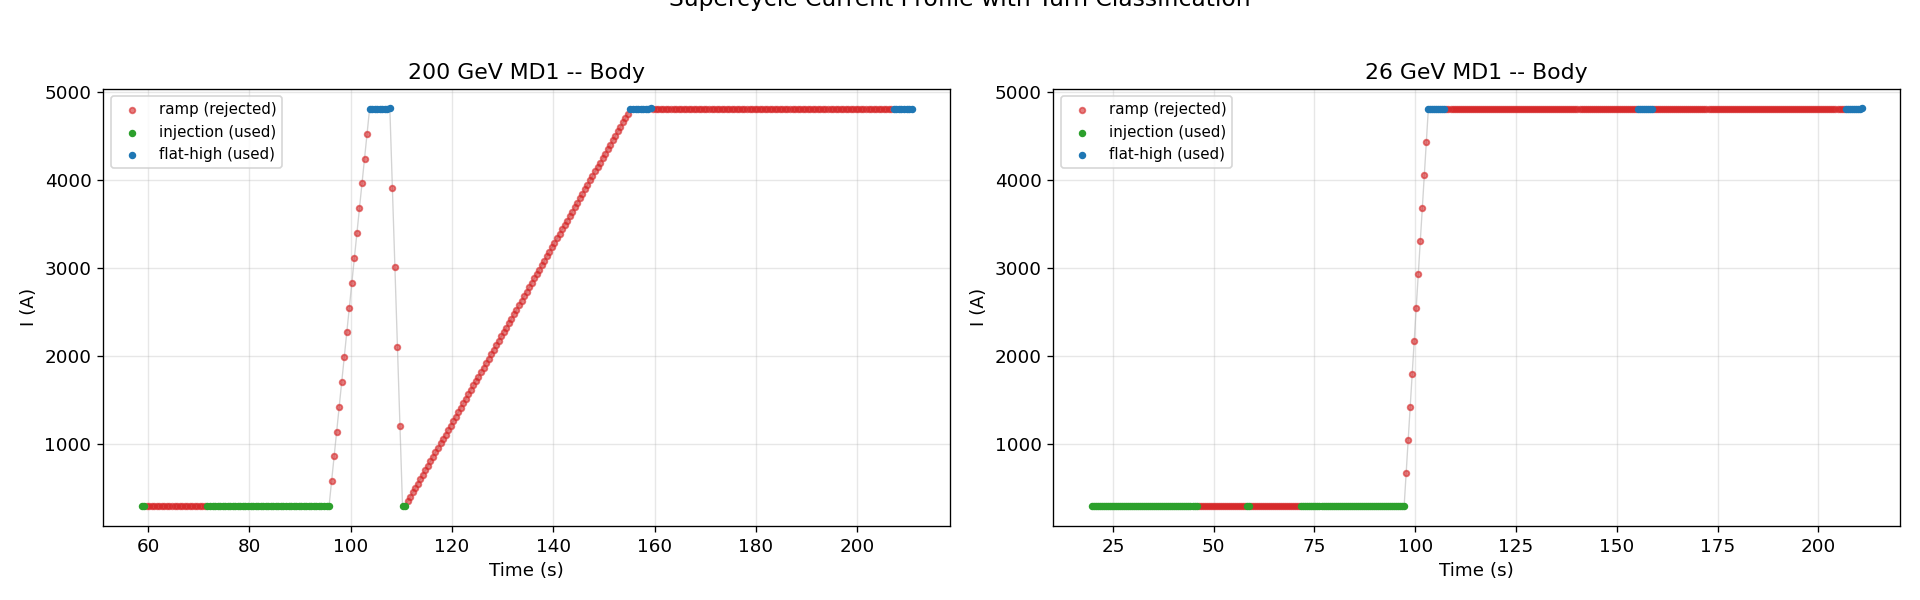

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, energy in zip(axes, ENERGIES):
    df = plateau[(energy, BODY)].copy()
    # Pick 3 consecutive supercycles
    scs = sorted([s for s in df['sc_idx'].unique() if s >= 0])
    show = scs[1:4] if len(scs) >= 4 else scs[:3]
    sub = df[df['sc_idx'].isin(show)]

    # Ramp turns = gaps in global_turn
    gt = sorted(sub['global_turn'].unique())
    ramp_gt = sorted(set(range(min(gt), max(gt)+1)) - set(gt))
    if ramp_gt:
        t_r = np.interp(ramp_gt, sub['global_turn'], sub['time_s'])
        I_r = np.interp(ramp_gt, sub['global_turn'], sub['I_mean_A'])
        ax.scatter(t_r, I_r, s=12, color='tab:red', alpha=0.6, zorder=2, label='ramp (rejected)')

    for label, color in [('injection','tab:green'), ('flat-high','tab:blue')]:
        m = sub['label'] == label
        if m.any():
            ax.scatter(sub.loc[m,'time_s'], sub.loc[m,'I_mean_A'],
                       s=12, color=color, zorder=3, label=f'{label} (used)')

    # connecting line
    all_t = np.concatenate([sub['time_s'].values, t_r if ramp_gt else []])
    all_I = np.concatenate([sub['I_mean_A'].values, I_r if ramp_gt else []])
    o = np.argsort(all_t)
    ax.plot(all_t[o], all_I[o], '-', color='lightgrey', lw=0.8, zorder=0)
    ax.set_xlabel('Time (s)'); ax.set_ylabel('I (A)')
    ax.set_title(f'{EN_DISP[energy]} -- {DISP[BODY]}')
    ax.legend(fontsize=9, loc='upper left')

fig.suptitle('Supercycle Current Profile with Turn Classification', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'current_cycle.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Eddy-Current Settling

### Physics

When the current ramp ends and the injection plateau begins, the changing flux
has induced **eddy currents** in the beam pipe and yoke laminations. These decay
exponentially:

$$B(t) = B_\infty + \sum_i A_i \, e^{-t/\tau_i}$$

The time constants $\tau_i$ depend on geometry and resistivity of the conducting
structures (beam pipe $\sim$1 s, yoke laminations $\sim$2-4 s).

**Why it matters:** at injection (26 GeV MD1) the beam circulates for several
seconds. If $b_3$ is still drifting, the chromaticity changes and can cause
beam losses.

**Body vs fringe:** both see similar eddy amplitudes *in Tesla*, but the fringe
$B_1$ is 6x weaker, so the normalised $b_n = C_n/B_1 \times 10^4$ is amplified
~6x in the fringe. The fringe drives the settling requirement.

### Uncertainty band

We average $N \approx 20$ identical supercycles. The shaded band is
$\pm 1\,\text{SEM} = \pm \sigma/\sqrt{N}$: the uncertainty on the **mean**
settling curve, not the raw scatter. Outliers are removed with a two-pass
3$\sigma$ MAD filter per turn index before computing the mean.

In [3]:
def mean_sem_curve(inj_df, col):
    """Align supercycles by turn_in_group, compute mean +/- SEM.
    Two-pass MAD outlier rejection (3-sigma) per turn index."""
    scs = sorted(s for s in inj_df['sc_idx'].unique() if s >= 0)
    buckets = {}
    for sc in scs:
        sub = inj_df[inj_df['sc_idx'] == sc].sort_values('turn_in_group')
        for _, r in sub.iterrows():
            k = int(r['turn_in_group'])
            buckets.setdefault(k, {'t': [], 'y': []})
            buckets[k]['t'].append(r['t_since_inj_start'])
            buckets[k]['y'].append(r[col])
    ks = sorted(buckets)
    t_m, y_m, y_sem, ns = [], [], [], []
    for k in ks:
        ys = np.array(buckets[k]['y'])
        ts = np.array(buckets[k]['t'])
        # Two-pass MAD outlier rejection (3-sigma)
        for _ in range(2):
            med = np.median(ys)
            mad = np.median(np.abs(ys - med))
            if mad > 1e-15:
                ok = np.abs(ys - med) / mad * 0.6745 < 3.0
                if ok.sum() >= 3:
                    ys, ts = ys[ok], ts[ok]
        n = len(ys)
        t_m.append(np.mean(ts))
        y_m.append(np.mean(ys))
        y_sem.append(np.std(ys) / np.sqrt(n) if n > 1 else 0.0)
        ns.append(n)
    return np.array(t_m), np.array(y_m), np.array(y_sem), np.array(ns)

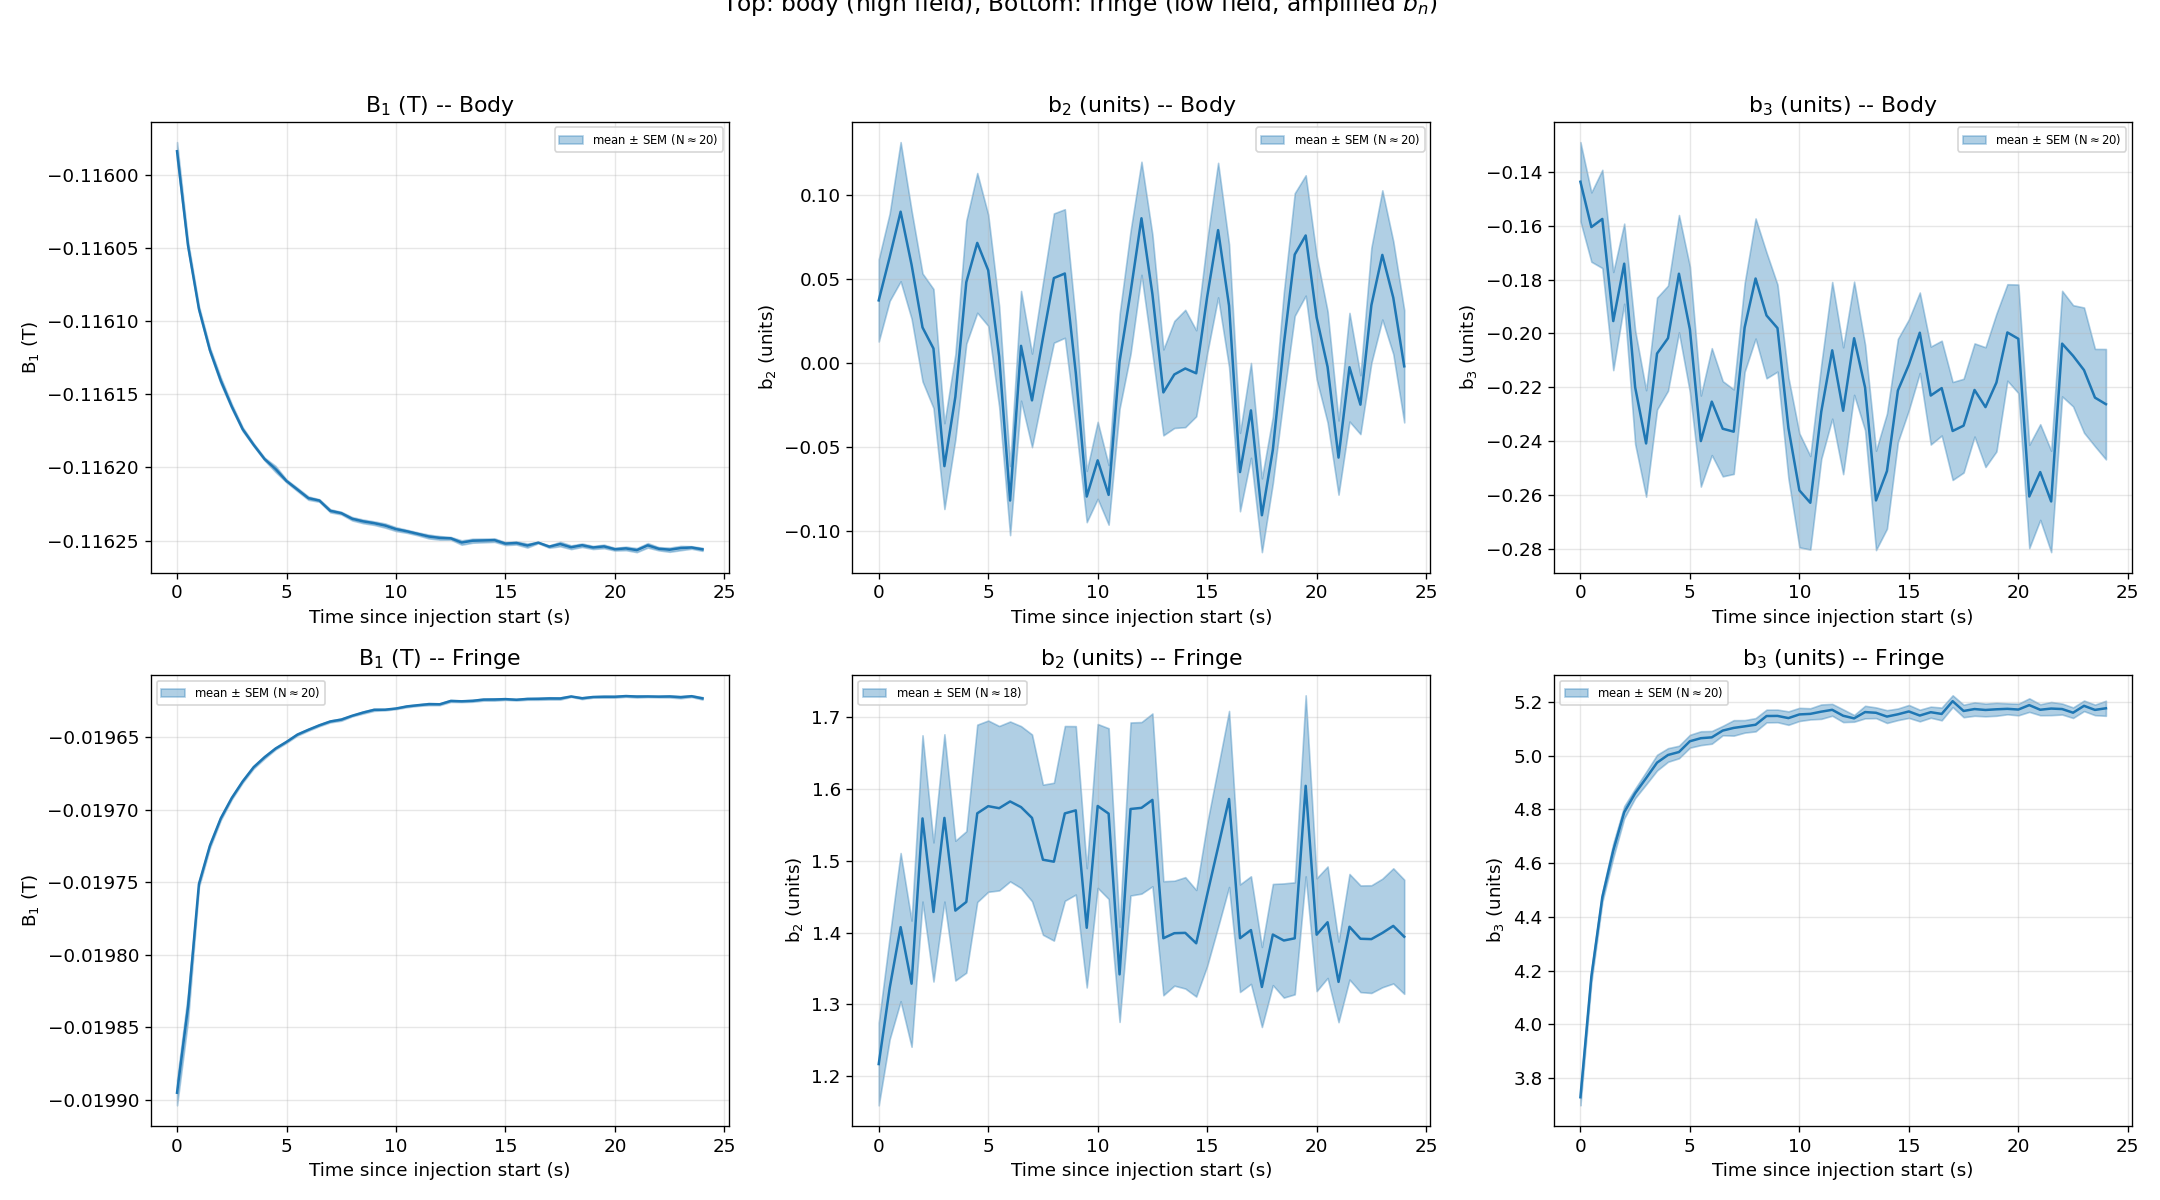

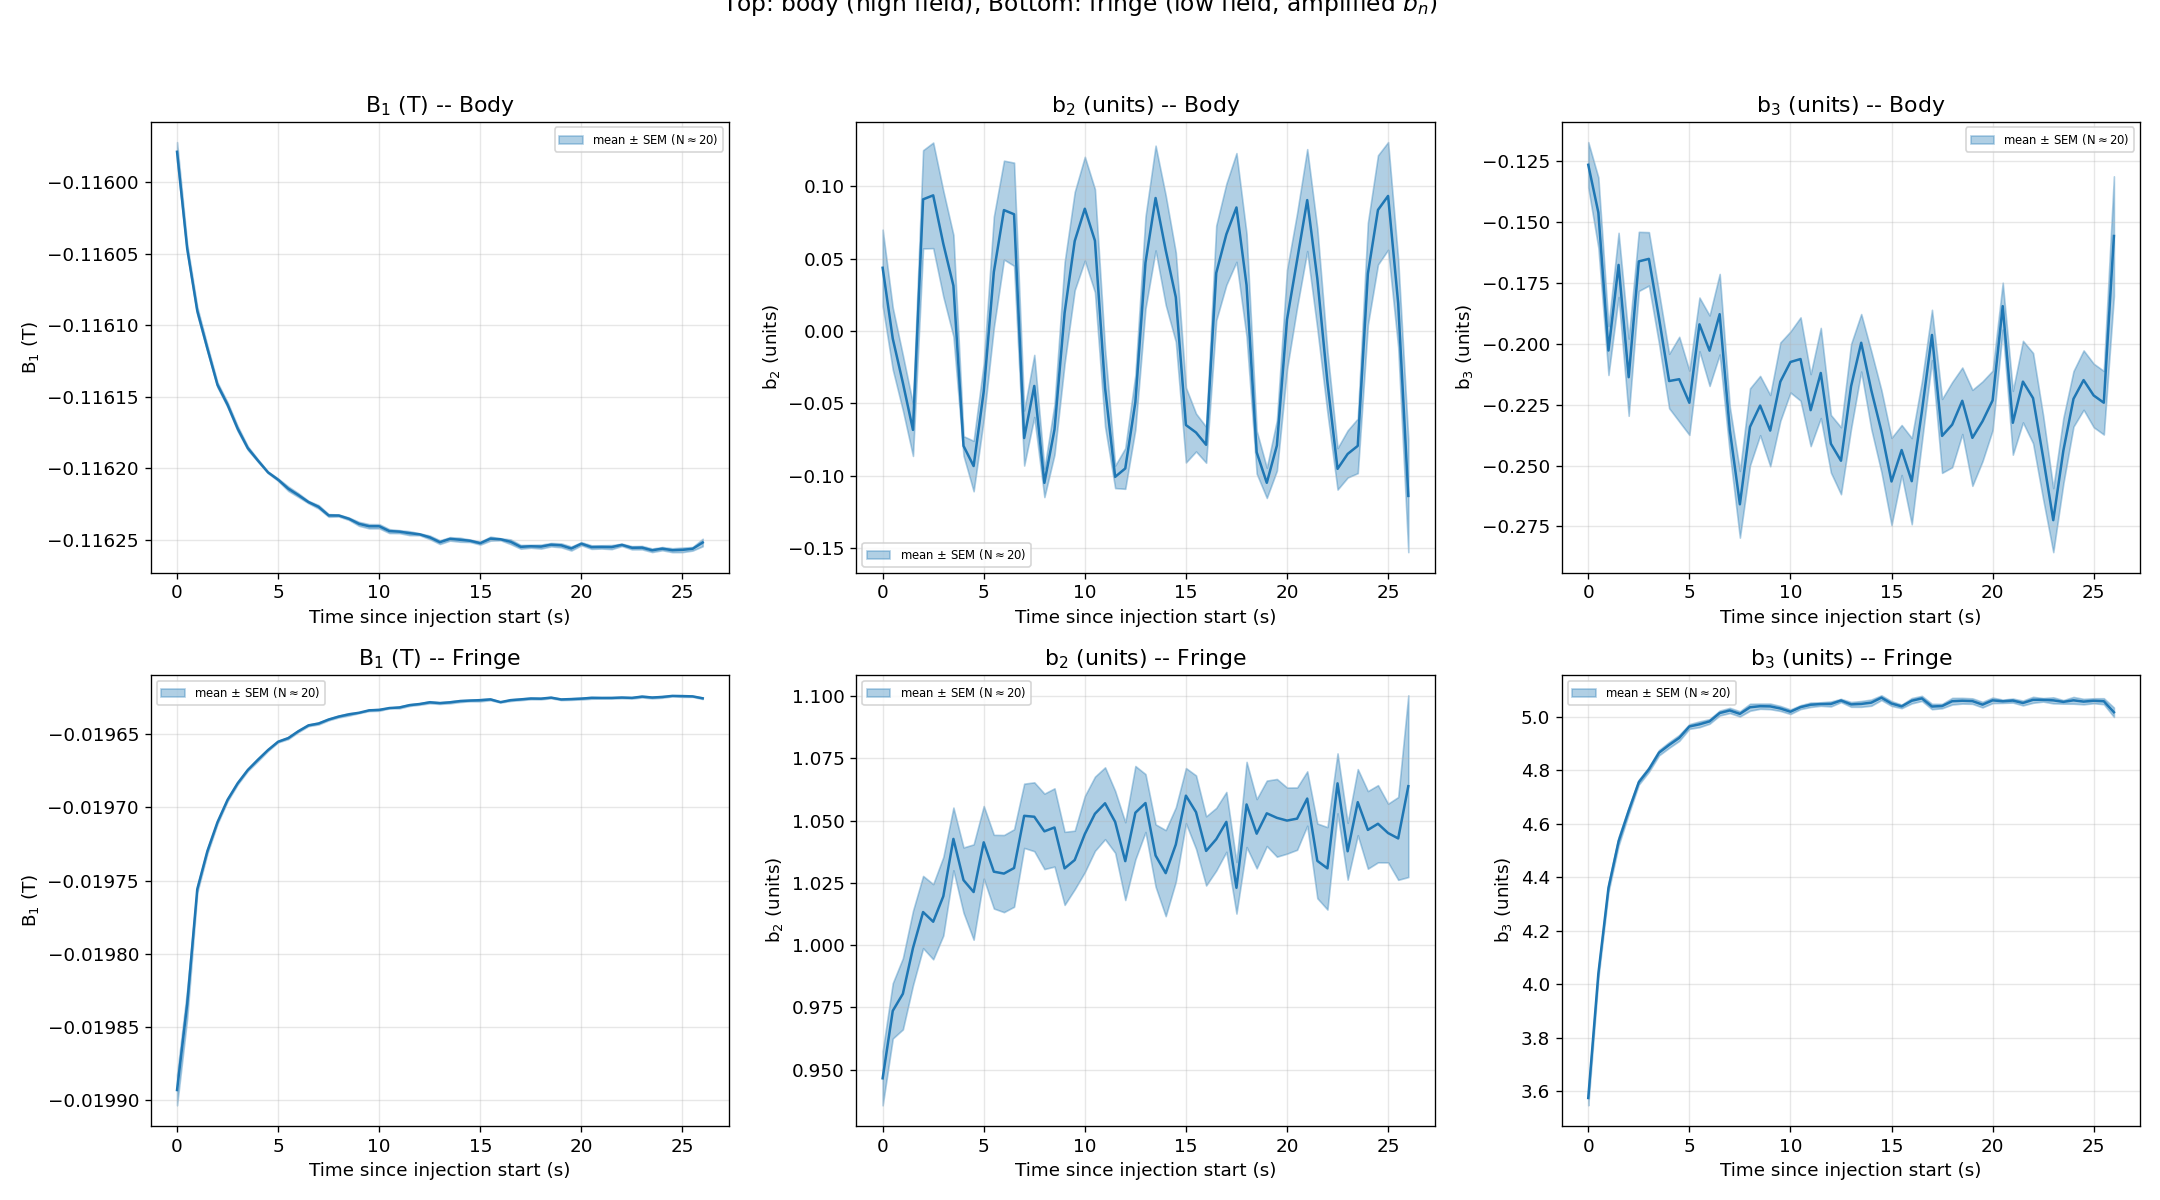

In [4]:
# Eddy quantities to plot
EDDY_Q = [('B1_T', 'B$_1$ (T)'), ('b2_units', 'b$_2$ (units)'), ('b3_units', 'b$_3$ (units)')]

for energy in ENERGIES:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    for row, seg in enumerate([BODY, FRINGE]):
        inj = eddy_inj[(energy, seg)]
        for col_i, (col, ylabel) in enumerate(EDDY_Q):
            ax = axes[row, col_i]
            t, y, sem, ns = mean_sem_curve(inj, col)

            # Mean +/- SEM
            ax.fill_between(t, y - sem, y + sem, alpha=0.35, color='tab:blue',
                            label=f'mean $\\pm$ SEM (N$\\approx${int(np.median(ns))})')
            ax.plot(t, y, '-', lw=1.5, color='tab:blue')

            # Best fit from pre-computed eddy_fits_mean
            fm = fits_mean[energy]
            row_fit = fm[(fm['segment'] == seg) & (fm['quantity'] == col.replace('_units','').replace('_T',''))]
            if not row_fit.empty:
                r = row_fit.iloc[0]
                t_fine = np.linspace(t.min(), t.max(), 500)
                if r['model'] == '2-tau':
                    y_fit = r['B_inf'] + r['A1']*np.exp(-t_fine/r['tau1_s']) + r['A2']*np.exp(-t_fine/r['tau2_s'])
                    fit_lbl = (f"2-$\\tau$: $\\tau_1$={r['tau1_s']:.2f}, "
                               f"$\\tau_2$={r['tau2_s']:.2f} s, R$^2$={r['R2']:.4f}")
                else:
                    y_fit = r['B_inf'] + r['A1']*np.exp(-t_fine/r['tau1_s'])
                    fit_lbl = f"1-$\\tau$: $\\tau$={r['tau1_s']:.2f} s, R$^2$={r['R2']:.4f}"
                ax.plot(t_fine, y_fit, '--', lw=2, color='tab:red', label=fit_lbl)
                ax.axhline(r['B_inf'], color='gray', ls=':', lw=1, alpha=0.7,
                           label=f"$B_\\infty$ = {r['B_inf']:.6f}")

            ax.set_xlabel('Time since injection start (s)')
            ax.set_ylabel(ylabel)
            ax.set_title(f'{ylabel} -- {DISP[seg]}')
            ax.legend(fontsize=7, loc='best')

    fig.suptitle(f'Eddy-Current Settling -- {EN_DISP[energy]}\n'
                 'Top: body (high field), Bottom: fringe (low field, amplified $b_n$)',
                 fontsize=14, y=1.03)
    fig.tight_layout()
    fig.savefig(PLOT_DIR / f'eddy_settling_{EN_SLUG[energy]}.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 4. Eddy-Current Fit Summary

### Best-fit time constants from pre-computed analysis

In [5]:
# Combine both energies' fit summaries
rows = []
for en in ENERGIES:
    fm = fits_mean[en].copy()
    fm.insert(0, 'energy', EN_DISP[en])
    fm['segment_role'] = fm['segment'].map(DISP)
    rows.append(fm)
all_fits = pd.concat(rows, ignore_index=True)
display(all_fits[['energy','segment_role','quantity','model','R2',
                  'B_inf','A1','tau1_s','A2','tau2_s']].round(4))

,energy,segment_role,quantity,model,R2,B_inf,A1,tau1_s,A2,tau2_s
0,200 GeV MD1,Body,B1_T,1-tau,0.5961,-0.1163,0.0001,8.0801,NaN,NaN
1,200 GeV MD1,Body,b2_units,1-tau,0.0924,0.0189,0.0424,2.3833,NaN,NaN
2,200 GeV MD1,Body,b3_units,1-tau,0.4344,-0.2262,0.0796,2.6067,NaN,NaN
3,200 GeV MD1,Fringe,B1_T,2-tau,0.9956,-0.0196,-0.0002,0.9765,-0.0001,4.0588
4,200 GeV MD1,Fringe,b2_units,1-tau,0.8317,1.6169,-0.0918,12.1287,NaN,NaN
5,200 GeV MD1,Fringe,b3_units,2-tau,0.9989,5.1731,-0.9320,0.9482,-0.5128,3.4428
6,26 GeV MD1,Body,B1_T,1-tau,0.6604,-0.1163,0.0001,7.0106,NaN,NaN
7,26 GeV MD1,Body,b2_units,1-tau,0.0229,-0.9038,0.9373,1000.0000,NaN,NaN
8,26 GeV MD1,Body,b3_units,1-tau,0.4449,-0.2264,0.0838,3.0745,NaN,NaN
9,26 GeV MD1,Fringe,B1_T,2-tau,0.9968,-0.0196,-0.0002,1.0087,-0.0001,4.0829


### Physical interpretation

| Component | Material | Expected $\tau$ | Observed |
|-----------|----------|----------------|----------|
| Beam pipe | Stainless steel | ~0.5-1 s | $\tau_1 \approx 0.95$ s (fringe B$_1$, b$_3$) |
| Yoke laminations | Si-steel | ~2-5 s | $\tau_2 \approx 3.5$ s (fringe B$_1$, b$_3$) |

The body segment shows weak eddy signals (R$^2$ < 0.7 for B$_1$, <0.1 for b$_2$)
because the large B$_1$ denominator suppresses normalised amplitudes. Only the
fringe segment, where B$_1$ is ~6x smaller, shows clean exponential decays.

**The fringe b$_3$ is the critical quantity** for SPS operations: it settles with
$\tau_1 \approx 0.7-0.95$ s and $\tau_2 \approx 2.3-3.4$ s. At $N_{\text{last}} = 18$
turns (= 9 s at 2 Hz), the eddy residual is $e^{-9/3.4} \approx 7\%$ of initial
amplitude, or ~0.07 units -- well below the SPS tolerance of ~1 unit.

### How to compute the settled field

**Primary estimator:** average the last $N$ turns on the injection plateau
(model-free, robust). The fitted $B_\infty$ is a diagnostic cross-check.

**Key metric:** $|\Delta|/\sigma = |B_\infty - \text{last-N mean}| \,/\, (\sigma/\sqrt{N_{SC}})$.
If < 1, the eddy bias is smaller than measurement scatter and can be ignored.

### Model selection: AICc

Adding time constants always improves R$^2$ but risks overfitting. The corrected
Akaike Information Criterion penalises model complexity:

$$\text{AICc} = n\ln(SS_{\text{res}}/n) + 2k + \frac{2k(k+1)}{n-k-1}$$

For weak signals (body b$_2$, b$_3$), AICc correctly picks 1-$\tau$. For strong
signals (fringe B$_1$, b$_3$), it selects 2-$\tau$, matching the two physical
eddy sources.

---
## 6. Harmonic Spectra

### Three views per energy

| Column | What it shows |
|--------|--------------|
| **Body + Fringe + Integrated (linear)** | Signed $b_n$ for all three. Shows why integrated $b_3$ can be large: the fringe $b_3 \approx 5$ units dominates despite its short length, because $b_n = C_n / B_1 \times 10^4$ amplifies when $B_1$ is small. |
| **Body (log)** | $|b_n|$ on log scale for the body segment. The downward slope = real multipoles; the horizontal plateau = noise floor. |
| **Fringe (log)** | Same for the fringe segment. The fringe has lower $B_1$ so the noise floor in units is **higher**, but the dominant harmonics ($b_3$, $b_5$) stand out more clearly because they are physically amplified by the weak dipole field. |

### Reading the log plot

Real multipoles decay geometrically: $|b_n| \propto (R_\text{ref}/R)^n$, which
is a **straight line with negative slope** on a log plot. Measurement noise
(ADC, vibrations, bucking residuals) adds a **constant floor** independent of $n$.

- **Downward slope** at low $n$ → real signal
- **Horizontal plateau** at high $n$ → noise floor
- The **transition** tells you up to which order the measurement is trustworthy
- **Allowed harmonics** ($b_3$, $b_5$, $b_7$) can stick out above the trend

### Noise floor and harmonic detection

The **red dashed line** is the estimated measurement noise floor, computed from
the **supercycle-to-supercycle scatter** of each $b_n$:

$$\sigma_n = \text{std}_{SC}\!\bigl(\overline{b_n}\bigr), \qquad
  \text{noise floor line} = \text{median}_n(\sigma_n)$$

The line is a visual reference for the typical noise level. But each harmonic
is coloured or greyed out based on its own **per-harmonic SNR**:

$$\text{SNR}_n = \frac{|\overline{b_n}|}{\sigma_n}$$

A harmonic is coloured (detected) if $\text{SNR}_n > 2$, i.e. its mean value
is more than twice its own supercycle scatter.

This avoids the pitfall of a single global threshold: a harmonic sitting on the
smooth decay curve (e.g. $b_5$ in the body) may have a small absolute value but
is highly **repeatable** across supercycles — low $\sigma_n$ → high SNR →
correctly identified as real signal. Conversely, a harmonic with a larger
absolute value but huge scatter is correctly flagged as unreliable.

### Dipole field B$_1$ summary

Before looking at the normalised harmonics, it is important to know the
**absolute dipole field** $B_1$ in each segment. Since $b_n = C_n / B_1 \times 10^4$,
a small $B_1$ (fringe) amplifies both signal and noise in units.

- **Body / Fringe**: $B_1$ in Tesla (T) — field averaged over coil length (470 mm).
- **Integrated**: $\int B_1 \, dl$ in Tesla-metres (Tm) — what the beam sees (total bending strength).

,Energy,Plateau,B1 Body (T),B1 Fringe (T),B1 Integrated (T),B1 Integrated (Tm),Ratio Body/Fringe
0,200 GeV MD1,Injection (300 A),-0.116255,-0.019622,-0.101744,0.702797,5.9
1,200 GeV MD1,Flat-top (4800 A),-1.781715,-0.291179,-1.557897,10.762071,6.1
2,26 GeV MD1,Injection (300 A),-0.116255,-0.019625,-0.101745,0.702804,5.9
3,26 GeV MD1,Flat-top (4800 A),-1.781749,-0.291240,-1.557935,10.762328,6.1


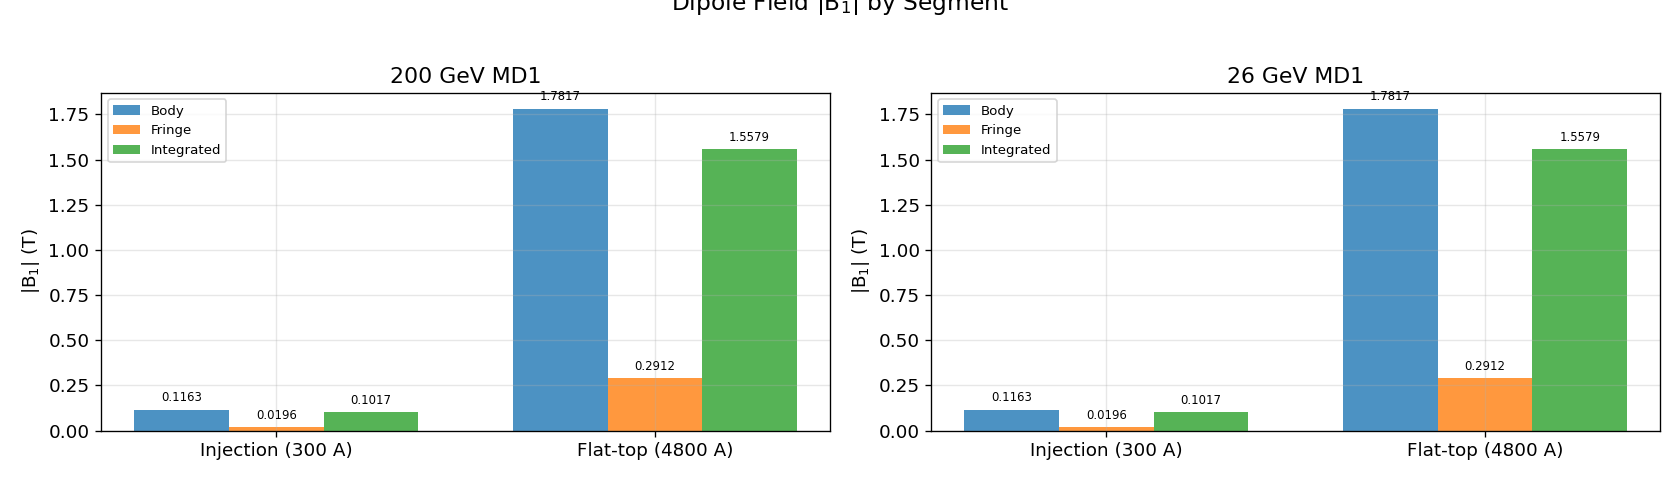

In [6]:
# Coil / magnet geometry
L_COIL = 0.470    # m, coil length
L_MAGNET = 6.260  # m, total magnetic length
L_BODY = L_MAGNET - 2 * L_COIL  # body effective length
L_TOTAL = L_MAGNET

label_disp = {'injection': 'Injection (300 A)', 'flat-high': 'Flat-top (4800 A)'}

# Load integrated field summary (has B_int in Tm)
int_field_summary = pd.read_csv(OUT / 'integrated_field' / 'integrated_field_summary.csv')

b1_rows = []
for energy in ENERGIES:
    for label in ['injection', 'flat-high']:
        b1_body = settled[(energy, BODY)].query(f'label == "{label}"')['B1_T'].mean()
        b1_fringe = settled[(energy, FRINGE)].query(f'label == "{label}"')['B1_T'].mean()
        b1_int = (b1_body * L_BODY + 2 * b1_fringe * L_COIL) / L_TOTAL
        # Get B_int in Tm from the integrated field summary
        row_int = int_field_summary[(int_field_summary['energy'] == energy) &
                                     (int_field_summary['label'] == label)]
        b1_int_Tm = row_int['B_int_Tm'].values[0] if not row_int.empty else b1_body * L_BODY + 2 * b1_fringe * L_COIL
        b1_rows.append({
            'Energy': EN_DISP[energy],
            'Plateau': label_disp[label],
            'B1 Body (T)': f'{b1_body:.6f}',
            'B1 Fringe (T)': f'{b1_fringe:.6f}',
            'B1 Integrated (T)': f'{b1_int:.6f}',
            'B1 Integrated (Tm)': f'{b1_int_Tm:.6f}',
            'Ratio Body/Fringe': f'{abs(b1_body/b1_fringe):.1f}',
        })

b1_table = pd.DataFrame(b1_rows)
display(b1_table)

# === Combined plot (all three segments, in T) ===
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, energy in zip(axes, ENERGIES):
    labels_plt = []
    body_vals, fringe_vals, int_vals = [], [], []
    for label in ['injection', 'flat-high']:
        b1_body = abs(settled[(energy, BODY)].query(f'label == "{label}"')['B1_T'].mean())
        b1_fringe = abs(settled[(energy, FRINGE)].query(f'label == "{label}"')['B1_T'].mean())
        b1_int = abs((settled[(energy, BODY)].query(f'label == "{label}"')['B1_T'].mean() * L_BODY
                     + 2 * settled[(energy, FRINGE)].query(f'label == "{label}"')['B1_T'].mean() * L_COIL) / L_TOTAL)
        labels_plt.append(label_disp[label])
        body_vals.append(b1_body)
        fringe_vals.append(b1_fringe)
        int_vals.append(b1_int)

    x = np.arange(len(labels_plt))
    w = 0.25
    ax.bar(x - w, body_vals, w, label='Body', color='tab:blue', alpha=0.8)
    ax.bar(x, fringe_vals, w, label='Fringe', color='tab:orange', alpha=0.8)
    ax.bar(x + w, int_vals, w, label='Integrated', color='tab:green', alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(labels_plt)
    ax.set_ylabel('|B$_1$| (T)'); ax.set_title(f'{EN_DISP[energy]}')
    ax.legend(fontsize=8)
    for i, (b, f, it) in enumerate(zip(body_vals, fringe_vals, int_vals)):
        ax.annotate(f'{b:.4f}', (i - w, b), textcoords='offset points',
                    xytext=(0, 5), ha='center', fontsize=7)
        ax.annotate(f'{f:.4f}', (i, f), textcoords='offset points',
                    xytext=(0, 5), ha='center', fontsize=7)
        ax.annotate(f'{it:.4f}', (i + w, it), textcoords='offset points',
                    xytext=(0, 5), ha='center', fontsize=7)

fig.suptitle('Dipole Field |B$_1$| by Segment', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'B1_summary.png', dpi=150, bbox_inches='tight')
plt.show()

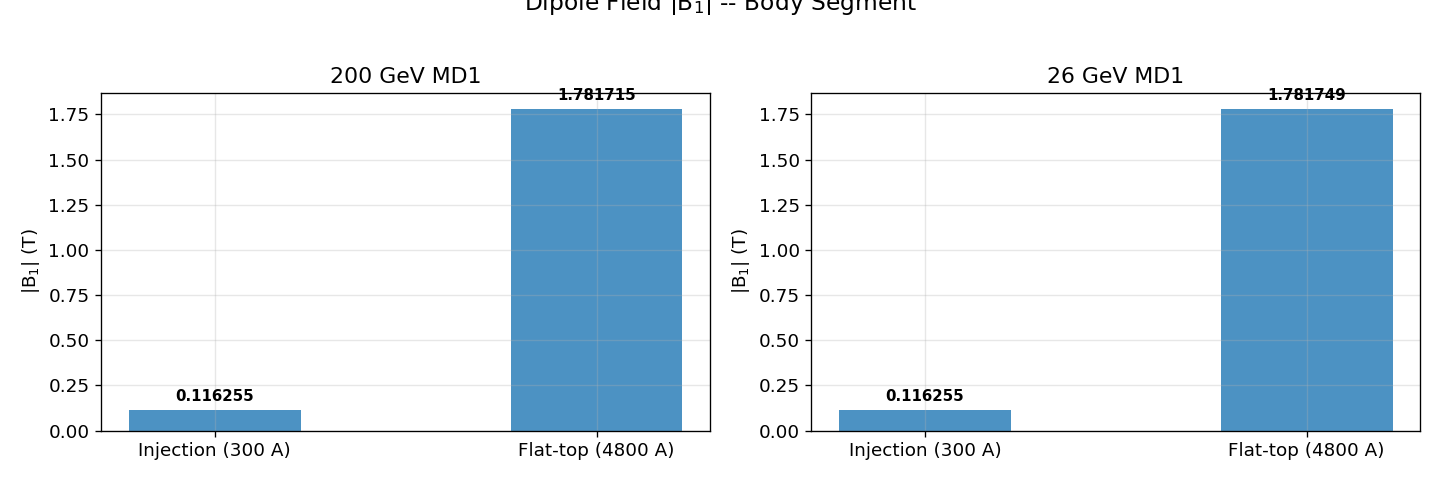

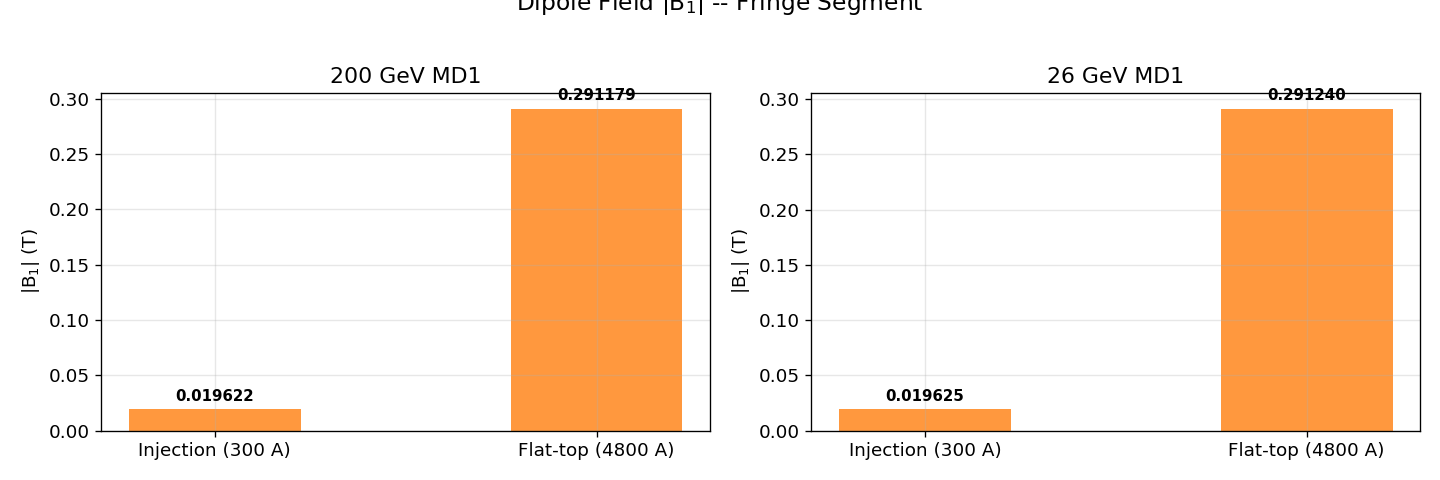

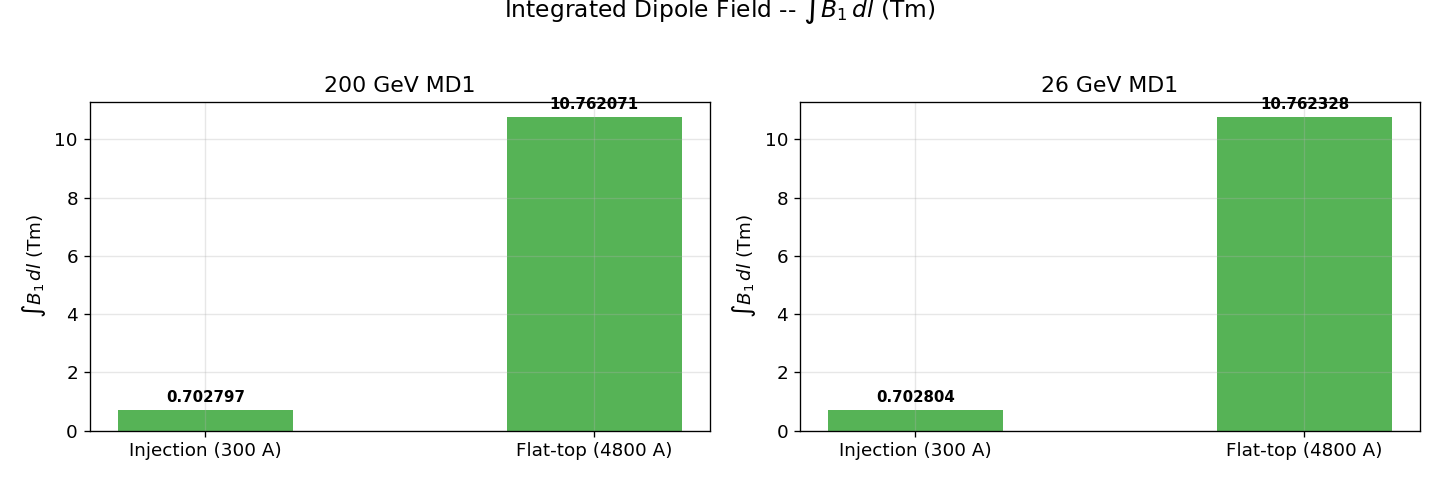

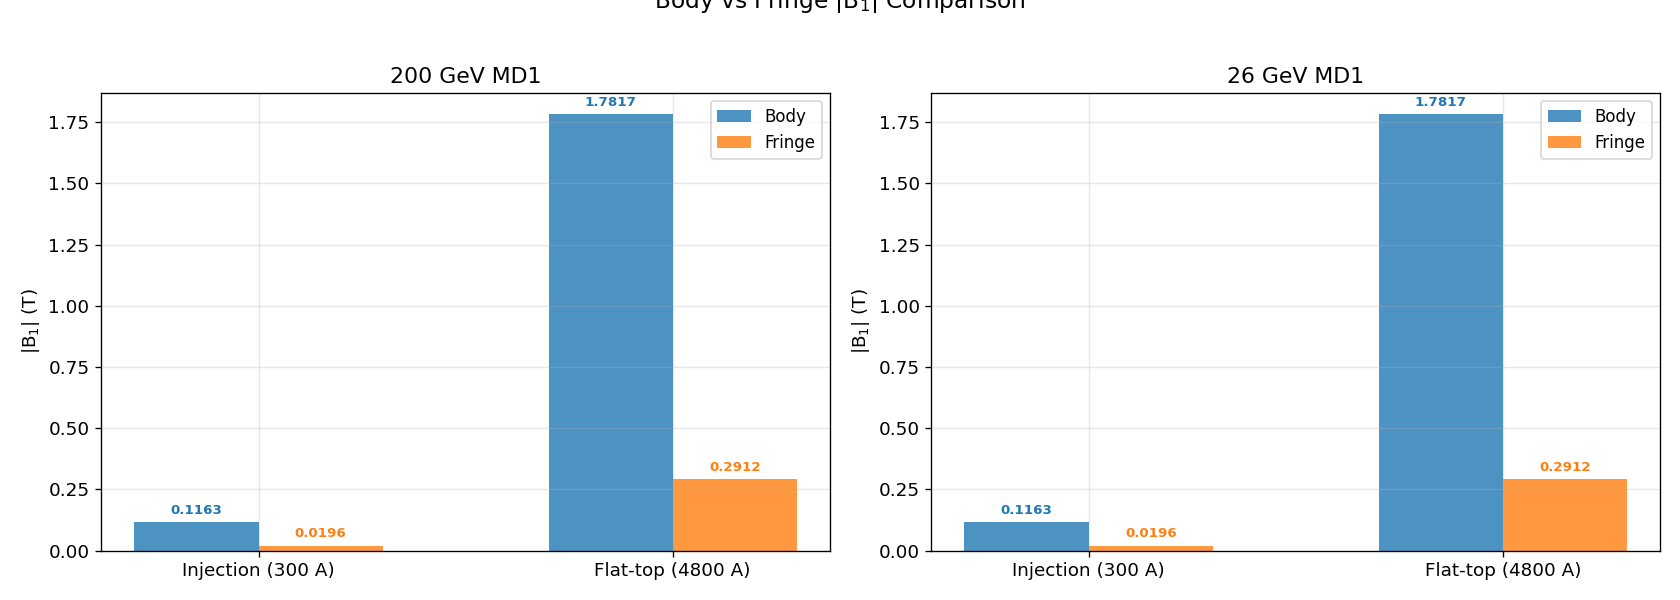

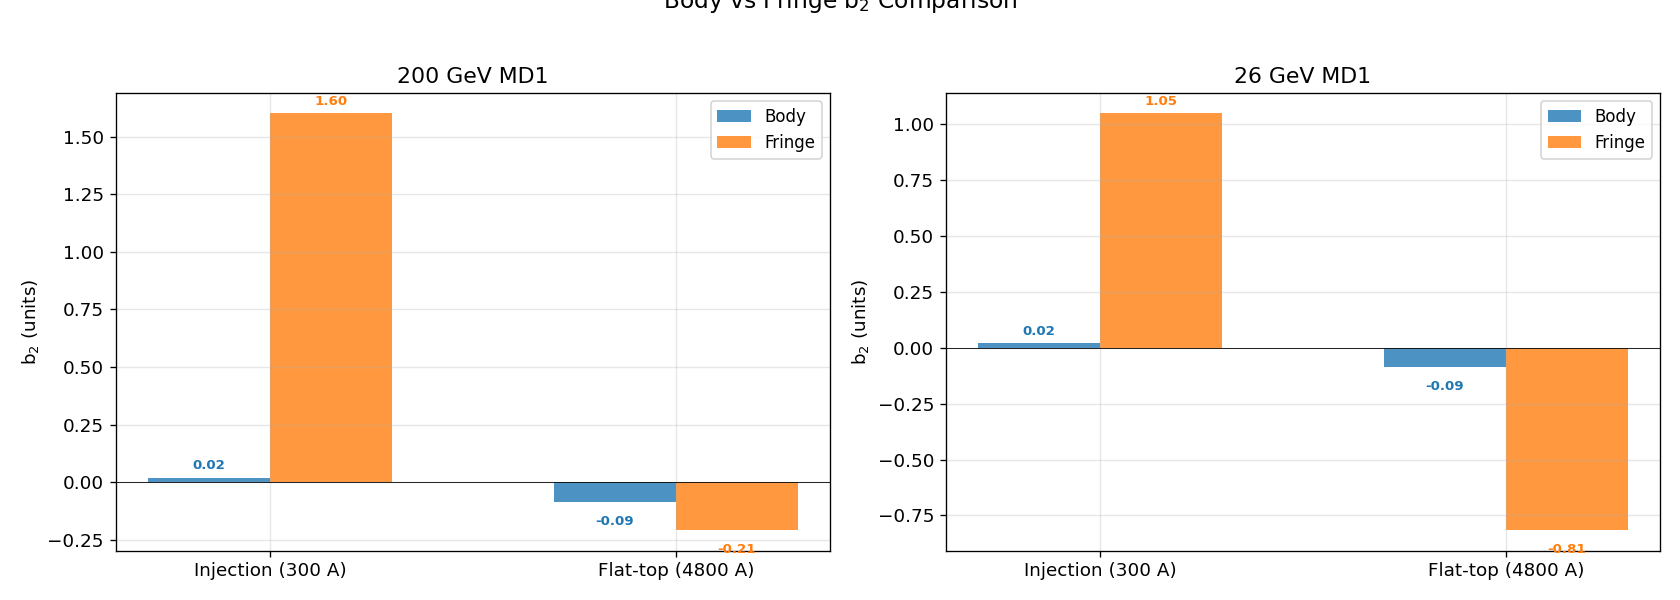

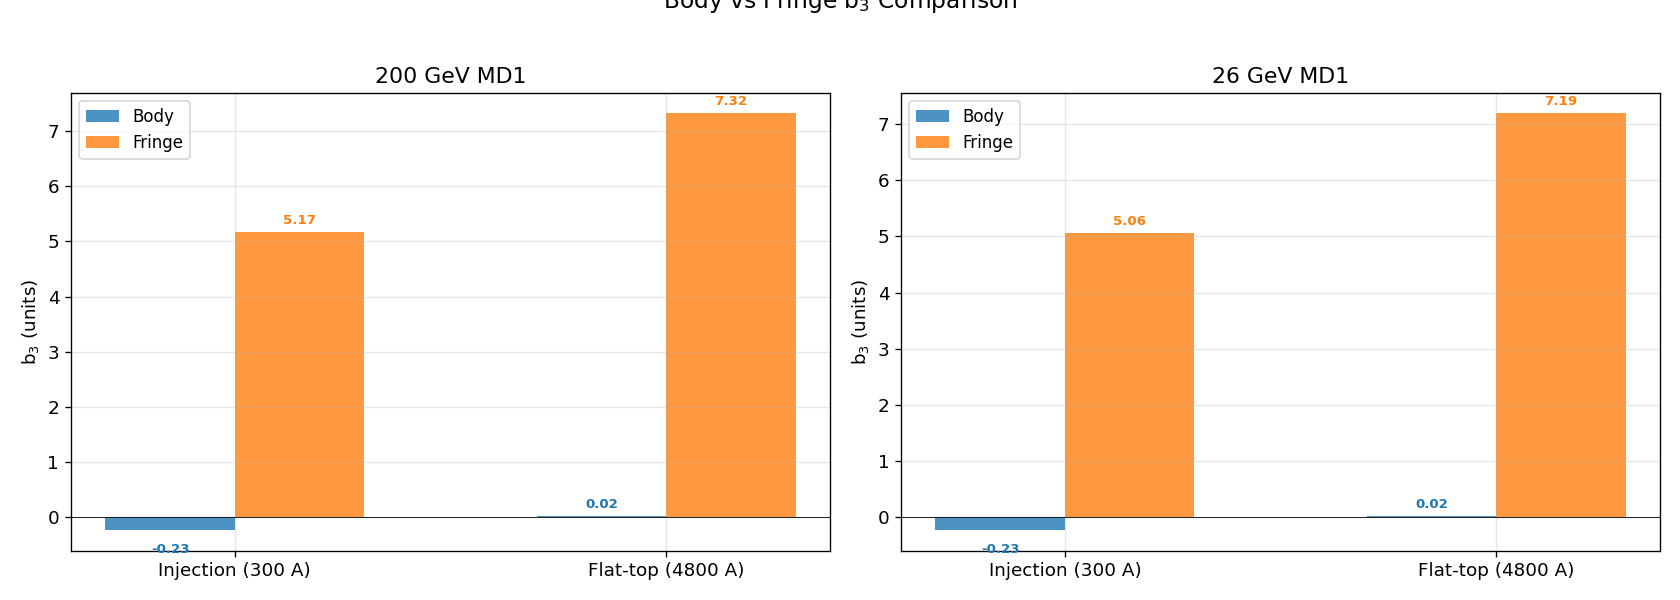

Saved: B1_body.png, B1_fringe.png, B1_integrated.png, B1_body_vs_fringe.png, b2_body_vs_fringe.png, b3_body_vs_fringe.png


In [7]:
# === Individual B1 plots: Body, Fringe, Integrated, Body+Fringe comparison ===

def _make_single_b1_plot(segment_label, get_vals_fn, ylabel, title, filename):
    """Make a single-segment B1 bar chart: both energies, injection + flat-top."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, energy in zip(axes, ENERGIES):
        labels_plt, vals = [], []
        for label in ['injection', 'flat-high']:
            labels_plt.append(label_disp[label])
            vals.append(get_vals_fn(energy, label))

        x = np.arange(len(labels_plt))
        colors = ['tab:blue' if segment_label == 'Body'
                  else 'tab:orange' if segment_label == 'Fringe'
                  else 'tab:green'] * len(x)
        ax.bar(x, vals, 0.45, color=colors, alpha=0.8)
        ax.set_xticks(x); ax.set_xticklabels(labels_plt)
        ax.set_ylabel(ylabel); ax.set_title(f'{EN_DISP[energy]}')
        for i, v in enumerate(vals):
            ax.annotate(f'{v:.6f}', (i, v), textcoords='offset points',
                        xytext=(0, 5), ha='center', fontsize=9, fontweight='bold')

    fig.suptitle(title, fontsize=14, y=1.02)
    fig.tight_layout()
    fig.savefig(PLOT_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()

# Body B1
_make_single_b1_plot(
    'Body',
    lambda en, lbl: abs(settled[(en, BODY)].query(f'label == "{lbl}"')['B1_T'].mean()),
    '|B$_1$| (T)',
    'Dipole Field |B$_1$| -- Body Segment',
    'B1_body.png',
)

# Fringe B1
_make_single_b1_plot(
    'Fringe',
    lambda en, lbl: abs(settled[(en, FRINGE)].query(f'label == "{lbl}"')['B1_T'].mean()),
    '|B$_1$| (T)',
    'Dipole Field |B$_1$| -- Fringe Segment',
    'B1_fringe.png',
)

# Integrated B1 in Tm
def _get_b1_int_Tm(en, lbl):
    row = int_field_summary[(int_field_summary['energy'] == en) &
                             (int_field_summary['label'] == lbl)]
    return abs(row['B_int_Tm'].values[0])

_make_single_b1_plot(
    'Integrated',
    _get_b1_int_Tm,
    '$\\int B_1 \\, dl$ (Tm)',
    'Integrated Dipole Field -- $\\int B_1 \\, dl$ (Tm)',
    'B1_integrated.png',
)

# === Body vs Fringe comparison: B1, b2, b3 ===

def _make_body_vs_fringe_plot(col, ylabel, title, filename, fmt='.4f', use_signed=False):
    """Body vs fringe grouped bar chart for any settled quantity."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, energy in zip(axes, ENERGIES):
        labels_plt, body_vals, fringe_vals = [], [], []
        for label in ['injection', 'flat-high']:
            labels_plt.append(label_disp[label])
            vb = settled[(energy, BODY)].query(f'label == "{label}"')[col].mean()
            vf = settled[(energy, FRINGE)].query(f'label == "{label}"')[col].mean()
            if use_signed:
                body_vals.append(vb)
                fringe_vals.append(vf)
            else:
                body_vals.append(abs(vb))
                fringe_vals.append(abs(vf))

        x = np.arange(len(labels_plt))
        w = 0.30
        ax.bar(x - w/2, body_vals, w, label='Body', color='tab:blue', alpha=0.8)
        ax.bar(x + w/2, fringe_vals, w, label='Fringe', color='tab:orange', alpha=0.8)
        ax.set_xticks(x); ax.set_xticklabels(labels_plt)
        ax.set_ylabel(ylabel); ax.set_title(f'{EN_DISP[energy]}')
        ax.legend(fontsize=10)
        if use_signed:
            ax.axhline(0, color='k', lw=0.5)

        for i, (b, f) in enumerate(zip(body_vals, fringe_vals)):
            ax.annotate(f'{b:{fmt}}', (i - w/2, b), textcoords='offset points',
                        xytext=(0, 5 if b >= 0 else -14), ha='center', fontsize=8,
                        fontweight='bold', color='tab:blue')
            ax.annotate(f'{f:{fmt}}', (i + w/2, f), textcoords='offset points',
                        xytext=(0, 5 if f >= 0 else -14), ha='center', fontsize=8,
                        fontweight='bold', color='tab:orange')

    fig.suptitle(title, fontsize=14, y=1.02)
    fig.tight_layout()
    fig.savefig(PLOT_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()

# B1 body vs fringe (absolute)
_make_body_vs_fringe_plot(
    'B1_T', '|B$_1$| (T)',
    'Body vs Fringe |B$_1$| Comparison',
    'B1_body_vs_fringe.png', fmt='.4f',
)

# b2 body vs fringe (signed -- shows polarity)
_make_body_vs_fringe_plot(
    'b2_units', 'b$_2$ (units)',
    'Body vs Fringe b$_2$ Comparison',
    'b2_body_vs_fringe.png', fmt='.2f', use_signed=True,
)

# b3 body vs fringe (signed)
_make_body_vs_fringe_plot(
    'b3_units', 'b$_3$ (units)',
    'Body vs Fringe b$_3$ Comparison',
    'b3_body_vs_fringe.png', fmt='.2f', use_signed=True,
)

print("Saved: B1_body.png, B1_fringe.png, B1_integrated.png, "
      "B1_body_vs_fringe.png, b2_body_vs_fringe.png, b3_body_vs_fringe.png")

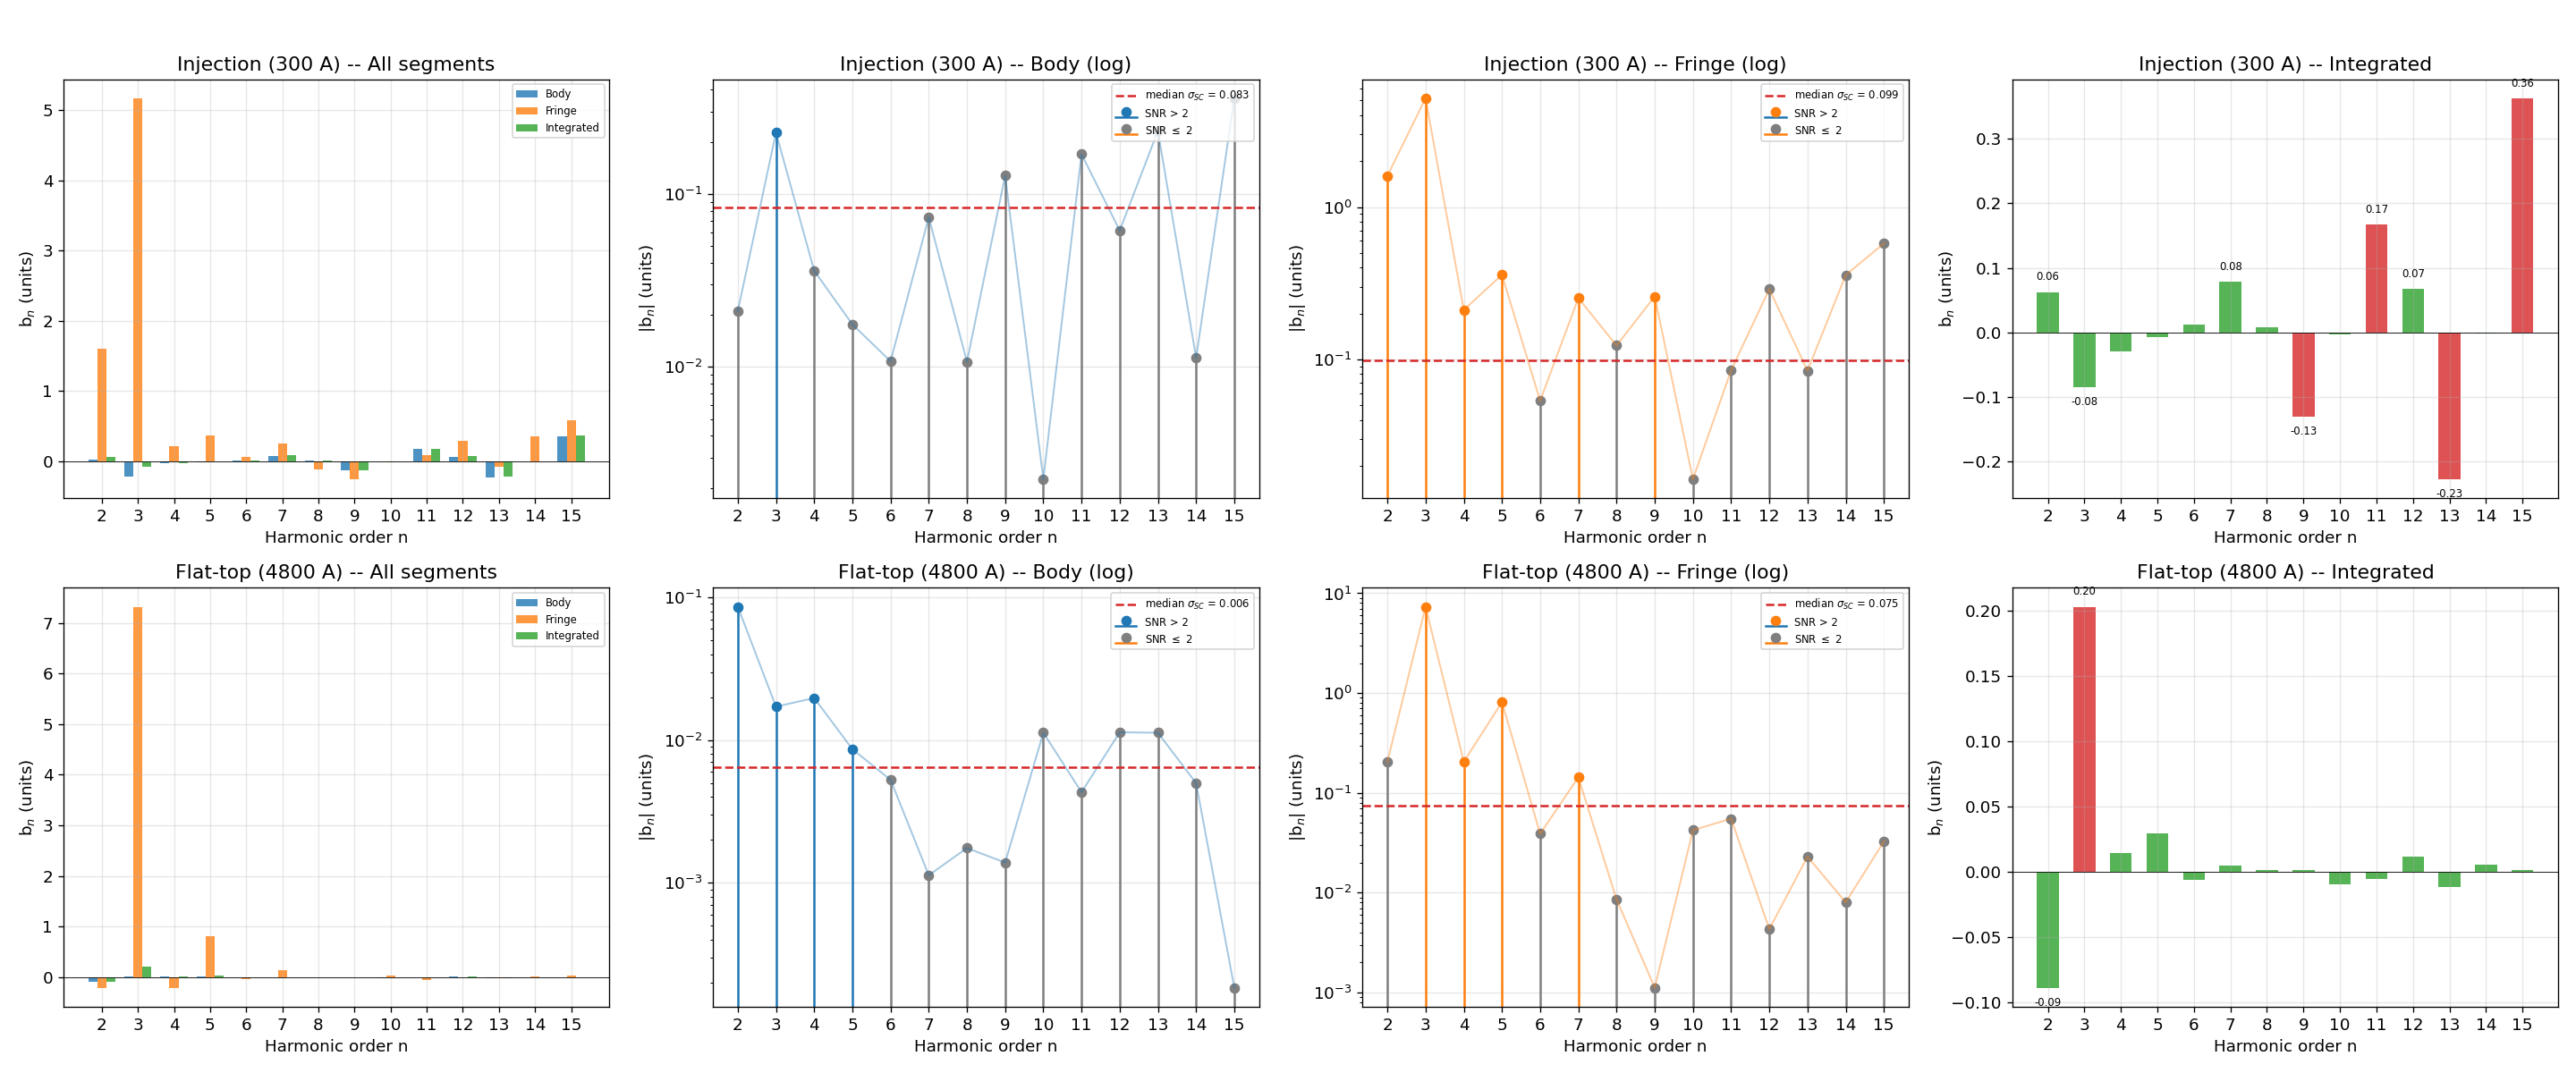

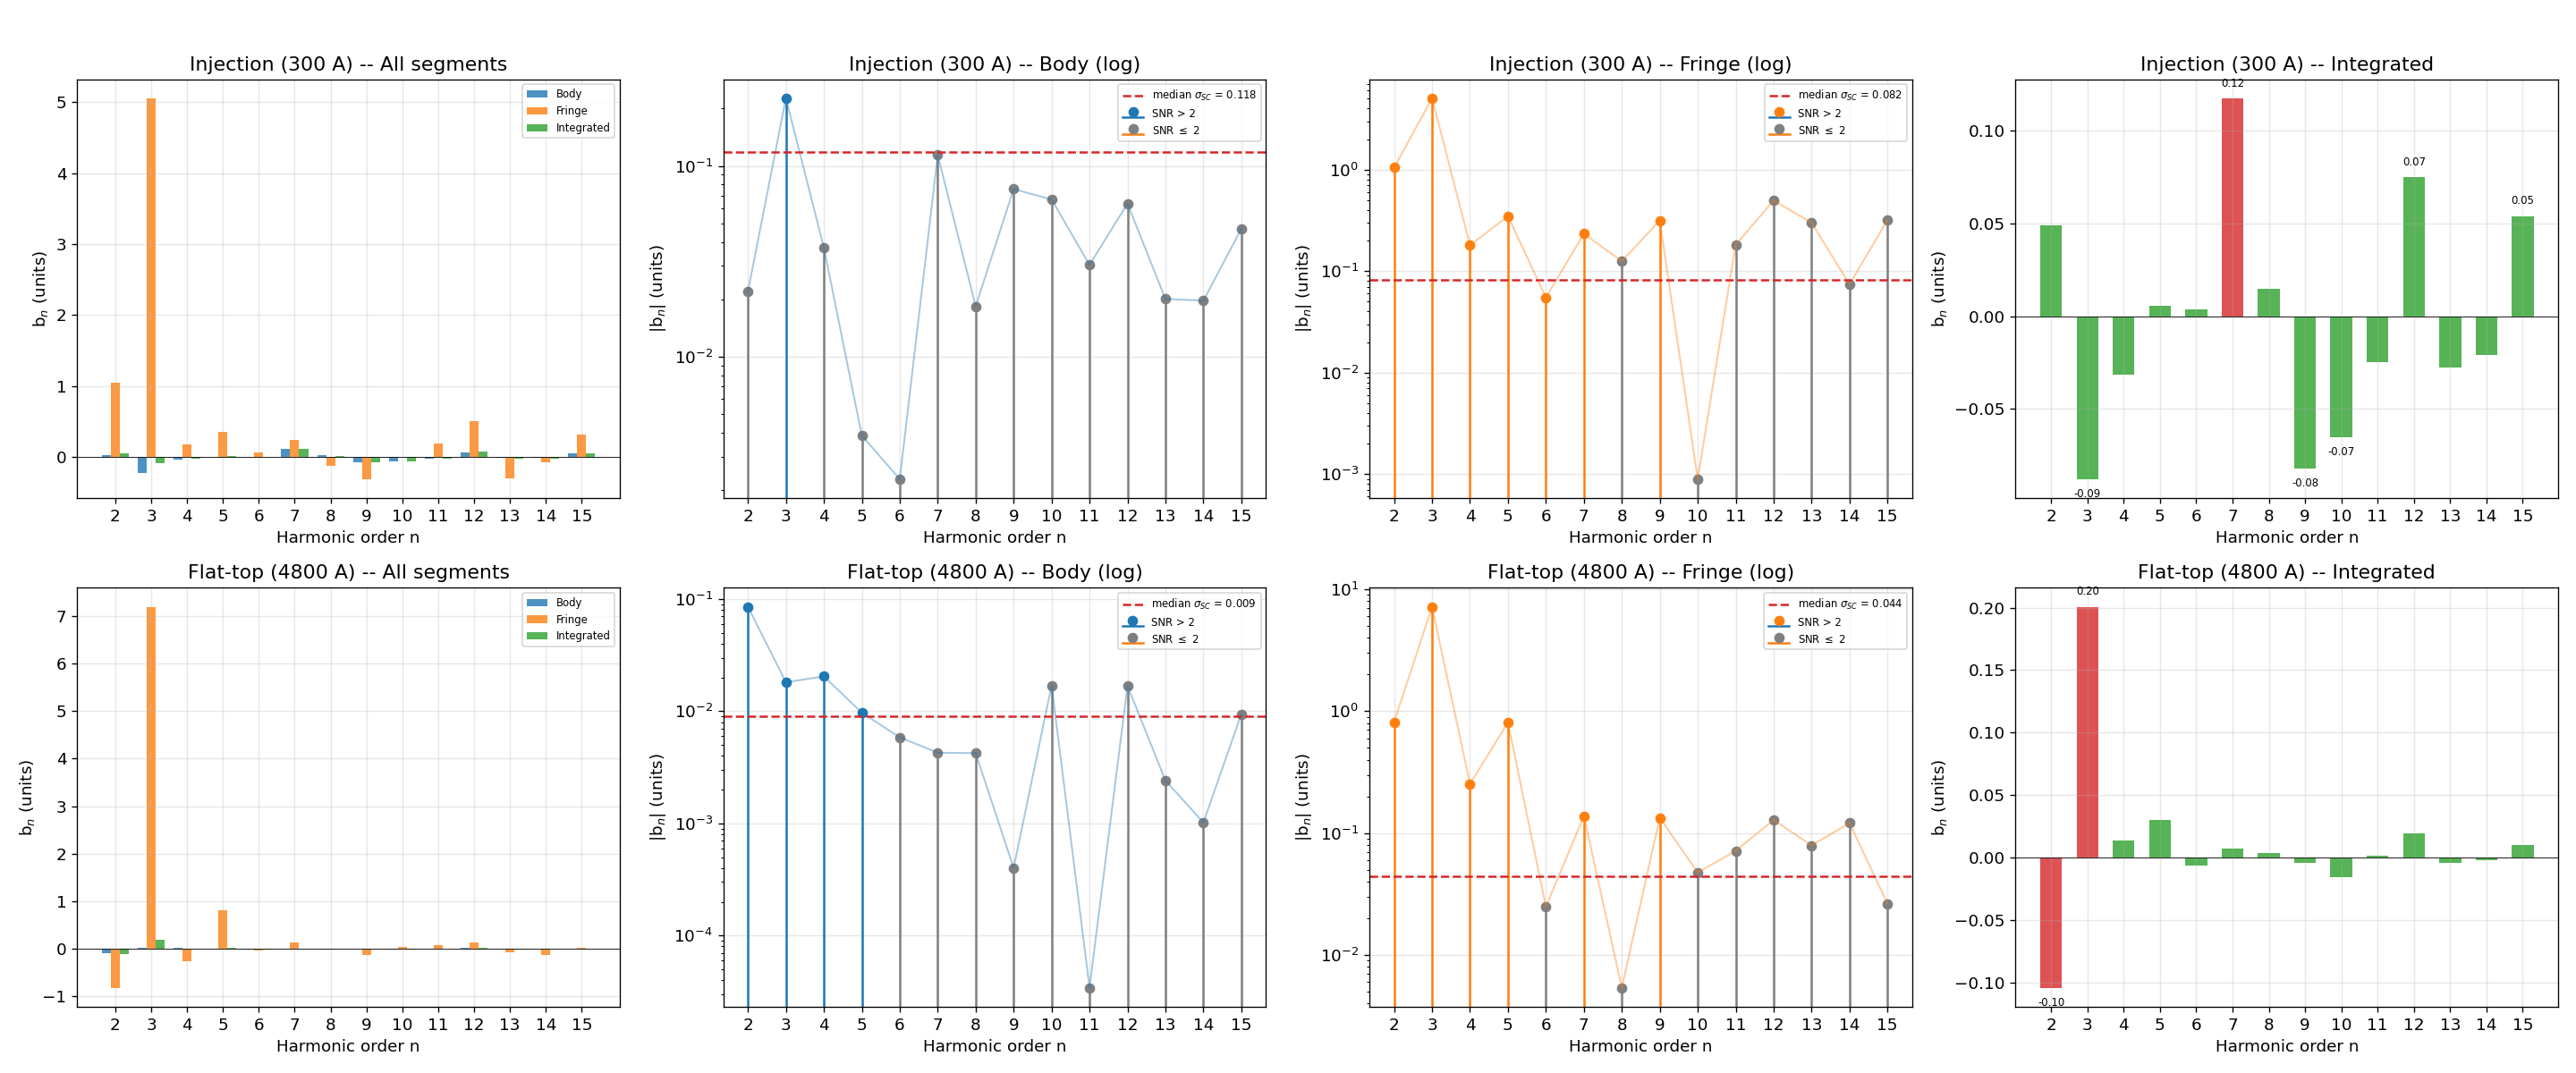

In [8]:
def noise_floor_from_scatter(df, harmonics):
    """Noise floor from supercycle-to-supercycle scatter.

    For each harmonic n, compute std(b_n) across supercycle means.
    Returns (median_sigma, per_harmonic_sigmas).
    - median_sigma: single number for the reference line
    - per_harmonic_sigmas: array for per-harmonic SNR detection
    """
    cols = [f'b{n}_units' for n in harmonics]
    if 'sc_idx' in df.columns and df['sc_idx'].nunique() > 2:
        sc_means = df.groupby('sc_idx')[cols].mean()
        sigmas = sc_means.std().values
    else:
        sigmas = np.array([df[c].std() for c in cols])
    return np.median(sigmas), sigmas


for energy in ENERGIES:
    fig, axes = plt.subplots(2, 4, figsize=(24, 10))

    for row, label in enumerate(['injection', 'flat-high']):
        body_df = settled[(energy, BODY)].query(f'label == "{label}"')
        fringe_df = settled[(energy, FRINGE)].query(f'label == "{label}"')
        ih = int_harmonics[(int_harmonics['energy']==energy) & (int_harmonics['label']==label)]

        x = np.array(HARMONICS)
        bn_body = np.array([body_df[f'b{n}_units'].mean() for n in HARMONICS])
        bn_fringe = np.array([fringe_df[f'b{n}_units'].mean() for n in HARMONICS])
        bn_int = np.array([ih[ih['n']==n]['bn_int'].values[0] if n in ih['n'].values else 0
                           for n in HARMONICS])
        w = 0.25

        # --- (a) Body + Fringe + Integrated (linear) ---
        ax = axes[row, 0]
        ax.bar(x - w, bn_body, w, label='Body', color='tab:blue', alpha=0.8)
        ax.bar(x, bn_fringe, w, label='Fringe', color='tab:orange', alpha=0.8)
        ax.bar(x + w, bn_int, w, label='Integrated', color='tab:green', alpha=0.8)
        ax.set_xlabel('Harmonic order n'); ax.set_ylabel('b$_n$ (units)')
        ax.set_title(f'{label_disp[label]} -- All segments')
        ax.set_xticks(x); ax.legend(fontsize=7); ax.axhline(0, color='k', lw=0.5)

        # --- (b) Body log ---
        abs_body = np.abs(bn_body)
        nf_body, sigmas_body = noise_floor_from_scatter(body_df, HARMONICS)
        ax = axes[row, 1]
        above_b = abs_body > 2 * sigmas_body  # per-harmonic SNR > 2
        if above_b.any():
            ax.stem(x[above_b], abs_body[above_b], linefmt='tab:blue',
                    markerfmt='o', basefmt='', label='SNR > 2')
        if (~above_b).any():
            ax.stem(x[~above_b], abs_body[~above_b], linefmt='tab:gray',
                    markerfmt='o', basefmt='', label='SNR $\\leq$ 2')
        ax.plot(x, abs_body, '-', color='tab:blue', alpha=0.4, lw=1.2)
        ax.set_yscale('log')
        ax.axhline(nf_body, color='tab:red', ls='--', lw=1.5,
                   label=f'median $\\sigma_{{SC}}$ = {nf_body:.3f}')
        ax.set_xlabel('Harmonic order n'); ax.set_ylabel('|b$_n$| (units)')
        ax.set_title(f'{label_disp[label]} -- Body (log)')
        ax.set_xticks(x); ax.legend(fontsize=7, loc='upper right')

        # --- (c) Fringe log ---
        abs_fringe = np.abs(bn_fringe)
        nf_fringe, sigmas_fringe = noise_floor_from_scatter(fringe_df, HARMONICS)
        ax = axes[row, 2]
        above_f = abs_fringe > 2 * sigmas_fringe  # per-harmonic SNR > 2
        if above_f.any():
            ax.stem(x[above_f], abs_fringe[above_f], linefmt='tab:orange',
                    markerfmt='o', basefmt='', label='SNR > 2')
        if (~above_f).any():
            ax.stem(x[~above_f], abs_fringe[~above_f], linefmt='tab:gray',
                    markerfmt='o', basefmt='', label='SNR $\\leq$ 2')
        ax.plot(x, abs_fringe, '-', color='tab:orange', alpha=0.4, lw=1.2)
        ax.set_yscale('log')
        ax.axhline(nf_fringe, color='tab:red', ls='--', lw=1.5,
                   label=f'median $\\sigma_{{SC}}$ = {nf_fringe:.3f}')
        ax.set_xlabel('Harmonic order n'); ax.set_ylabel('|b$_n$| (units)')
        ax.set_title(f'{label_disp[label]} -- Fringe (log)')
        ax.set_xticks(x); ax.legend(fontsize=7, loc='upper right')

        # --- (d) Integrated only ---
        ax = axes[row, 3]
        colors_int = ['tab:red' if abs(v) > 0.1 else 'tab:green' for v in bn_int]
        ax.bar(x, bn_int, 0.6, color=colors_int, alpha=0.8)
        ax.set_xlabel('Harmonic order n'); ax.set_ylabel('b$_n$ (units)')
        ax.set_title(f'{label_disp[label]} -- Integrated')
        ax.set_xticks(x); ax.axhline(0, color='k', lw=0.5)
        for n, v in zip(HARMONICS, bn_int):
            if abs(v) > 0.05:
                ax.annotate(f'{v:.2f}', (n, v), textcoords='offset points',
                            xytext=(0, 8 if v > 0 else -12), ha='center', fontsize=7)

    fig.suptitle(f'Harmonic Spectra -- {EN_DISP[energy]}',
                 fontsize=14, y=1.02)
    fig.tight_layout()
    fig.savefig(PLOT_DIR / f'harmonics_{EN_SLUG[energy]}.png', dpi=150, bbox_inches='tight')
    plt.show()

### Key observations

- **First column (linear)**: the fringe $b_3 \approx 5$ units dwarfs the body
  $b_3 \approx -0.2$ units. But the integrated $b_3$ is small because the body
  dominates by 12.5× in effective length and 6× in field strength.

- **Body log**: the body has excellent field quality — harmonics are small,
  so they reach the noise floor quickly. Only $b_3$ (and maybe $b_5$) are
  clearly above noise. This is **expected for a good dipole**: it means the
  iron geometry is clean with minimal higher-order multipole content.

- **Fringe log**: the fringe shows more harmonics above noise because
  $B_1$ is 6× weaker, so the same absolute $C_n$ gives 6× larger $b_n$ in
  units. The slope-to-plateau transition happens at higher $n$ — more
  harmonics are measurable but they describe the **fringe field shape**
  (end effects), not the beam-relevant integrated field.

- At **flat-top** (high current → high $B_1$), the noise floor drops in both
  segments and more harmonics become reliable.

- At **injection** (low current), the noise floor rises. The body log may
  show almost all harmonics near noise — this does **not** mean the magnet
  is bad, it means the field quality is better than the measurement
  sensitivity at this current.

- **Noise floor line**: the red dashed line is the median of the per-harmonic
  supercycle-to-supercycle $\sigma_n$ — a visual reference. But the
  colour/grey classification uses each harmonic's own $\sigma_n$
  (per-harmonic SNR > 2), so a small but repeatable harmonic on the decay
  curve is correctly detected even if it sits near the line.

---
## 6. Export Markdown Reports

Each section is saved as a standalone `.md` file in `presentation_export/`
with the corresponding plot images embedded.

In [9]:
# --- Build eddy fit summary table as markdown ---
rows_md = []
for en in ENERGIES:
    fm = fits_mean[en].copy()
    fm.insert(0, 'energy', EN_DISP[en])
    fm['segment'] = fm['segment'].map(DISP)
    rows_md.append(fm)
fit_table_df = pd.concat(rows_md, ignore_index=True)
cols = ['energy','segment','quantity','model','R2','B_inf','A1','tau1_s','A2','tau2_s']
fit_sub = fit_table_df[cols].round(4)

header = '| ' + ' | '.join(cols) + ' |'
sep = '|' + '|'.join(['---'] * len(cols)) + '|'
table_rows = []
for _, r in fit_sub.iterrows():
    vals = [str(r[c]) if pd.notna(r[c]) else '' for c in cols]
    table_rows.append('| ' + ' | '.join(vals) + ' |')
fit_table_md = '\n'.join([header, sep] + table_rows)

# --- Build B1 summary table as markdown ---
b1_header = '| Energy | Plateau | B1 Body (T) | B1 Fringe (T) | B1 Integrated (Tm) | Ratio Body/Fringe |'
b1_sep = '|---|---|---|---|---|---|'
b1_trows = []
for _, r in b1_table.iterrows():
    b1_trows.append(f"| {r['Energy']} | {r['Plateau']} | {r['B1 Body (T)']} | {r['B1 Fringe (T)']} | {r['B1 Integrated (Tm)']} | {r['Ratio Body/Fringe']} |")
b1_table_md = '\n'.join([b1_header, b1_sep] + b1_trows)

# --- Write markdown files ---
md_files = {}

# 1. Current cycle
md_files['01_current_cycle.md'] = """\
# Current Cycle with Turn Classification

The SPS supercycle ramps the magnet current from ~300 A (injection) to ~4800 A
(flat-top) and back. The rotating coil measures continuously at 2 Hz.

Only turns sitting entirely on a **current plateau** (dI/dt \u2248 0) are
usable for precision field measurement. During ramps the field changes within
one rotation, mixing eddy currents with the quasi-static field.

- **Green:** injection plateau (~300 A) \u2014 used for eddy settling + low-field harmonics
- **Blue:** flat-top plateau (~4800 A) \u2014 used for high-field harmonics
- **Red:** ramp turns \u2014 rejected

![Current cycle](current_cycle.png)
"""

# 2. Eddy-current settling (read from file -- maintained separately)

# 3. Eddy fit summary (read from file -- maintained separately)

# 4. B1 summary
md_files['04_B1_summary.md'] = f"""\
# Dipole Field B\u2081 Summary

Before looking at normalised harmonics, it is important to know the
**absolute dipole field** B\u2081 in each segment. Since b_n = C_n / B\u2081 \u00d7 10\u2074,
a small B\u2081 (fringe) amplifies both signal and noise in units.

## Units

- **Body and Fringe**: B\u2081 in Tesla (T) -- the field averaged over the
  coil's 470 mm sensitive length.
- **Integrated**: the true field integral \u222bB\u2081 dl in Tesla-metres (Tm),
  i.e. B_body \u00d7 L_body + 2 \u00d7 B_fringe \u00d7 L_fringe. This is what the beam
  sees (total bending strength).

## Summary table

{b1_table_md}

## All segments combined

![B1 summary](B1_summary.png)

## Body only

![B1 body](B1_body.png)

## Fringe only

![B1 fringe](B1_fringe.png)

## Integrated field (Tm)

![B1 integrated](B1_integrated.png)

## Body vs Fringe comparison

![B1 body vs fringe](B1_body_vs_fringe.png)

## Key observations

- The body/fringe ratio is ~6:1 at both energies and both plateaus,
  confirming the coil straddles the magnet end (one segment inside the yoke,
  one outside).
- The integrated field at flat-top is ~10.76 Tm, corresponding to an
  effective magnetic length L_mag = B_int / B_body ~ 6.04 m (vs yoke
  length 6.26 m -- the 0.22 m difference is the fringe fall-off region).
- B\u2081 values are consistent across the two energy cycles (same magnet,
  same current plateaus), as expected.
"""

# 5. Harmonic spectra
md_files['05_harmonics.md'] = """\
# Harmonic Spectra

## Layout

| Column | Shows |
|--------|-------|
| **Body + Fringe + Integrated** | Signed b_n for all three segments (linear). Shows why integrated b\u2083 can be large: fringe b\u2083 \u2248 5 units dominates despite short length. |
| **Body (log)** | |b_n| on log scale. Downward slope = real multipoles; horizontal plateau = noise floor. |
| **Fringe (log)** | Same for fringe. Higher noise floor in units (weaker B\u2081), but dominant harmonics stand out more. |
| **Integrated** | What the beam sees. Body dominates by 12.5\u00d7 in length and 6\u00d7 in field. |

## Reading the log plot

Real multipoles decay as |b_n| \u221d (R_ref/R)^n \u2014 a straight line on log scale.
Noise adds a constant floor. The transition from slope to plateau tells you
up to which order the measurement is trustworthy.

## Noise floor and harmonic detection

The **red dashed line** is the estimated measurement noise floor, computed from
the **supercycle-to-supercycle scatter** of each b_n:

    sigma_n = std_SC(mean(b_n)),    noise floor line = median_n(sigma_n)

The line is a visual reference for the typical noise level. But each harmonic
is coloured or greyed out based on its own **per-harmonic SNR**:

    SNR_n = |mean(b_n)| / sigma_n

A harmonic is coloured (detected) if SNR_n > 2, i.e. its mean value is more
than twice its own supercycle scatter.

This avoids the pitfall of a single global threshold: a harmonic sitting on the
smooth decay curve (e.g. b_5 in the body) may have a small absolute value but
is highly **repeatable** across supercycles \u2014 low sigma_n \u2192 high SNR \u2192
correctly identified as real signal. Conversely, a harmonic with a larger
absolute value but huge scatter is correctly flagged as unreliable.

## 200 GeV MD1

![Harmonics 200 GeV MD1](harmonics_200GeV_MD1.png)

## 26 GeV MD1

![Harmonics 26 GeV MD1](harmonics_26GeV_MD1.png)

## Body vs Fringe: b\u2082

![b2 body vs fringe](b2_body_vs_fringe.png)

## Body vs Fringe: b\u2083

![b3 body vs fringe](b3_body_vs_fringe.png)

## Key observations

- **First column (linear)**: fringe b\u2083 \u2248 5 units dwarfs body b\u2083 \u2248 \u22120.2 units.
  The integrated b\u2083 is small because the body dominates in length and field.

- **Body log**: the body has excellent field quality \u2014 harmonics are small,
  reaching noise quickly. Only b\u2083 (and maybe b\u2085) are clearly above noise.
  This is **expected for a good dipole**: clean iron geometry with minimal
  higher-order content.

- **Fringe log**: more harmonics above noise because B\u2081 is 6\u00d7 weaker,
  amplifying b_n. These describe the **fringe field shape** (end effects),
  not the beam-relevant integrated field.

- At **flat-top** (high B\u2081), noise floor drops and more harmonics are reliable.

- At **injection** (low B\u2081), noise rises. Body harmonics near noise does
  **not** mean bad field quality \u2014 it means quality exceeds measurement
  sensitivity at this current.

- **Noise floor line**: the red dashed line is the median of sigma_n \u2014 a
  visual reference. The colour/grey classification uses each harmonic's own
  sigma_n (per-harmonic SNR > 2), so a small but repeatable harmonic on the
  decay curve is correctly detected even if it sits near the line.
"""

for fname, content in md_files.items():
    (PLOT_DIR / fname).write_text(content, encoding='utf-8')

print(f'Exported to {PLOT_DIR}:')
for f in sorted(PLOT_DIR.iterdir()):
    print(f'  {f.name}  ({f.stat().st_size / 1024:.1f} kB)')

Exported to C:\Users\albellel\python-projects\rotating-coil-analyzer\rotating_coil_analyzer\notebooks\SPS_MBB\2026-02-25_2Hz\presentation_export:
  01_current_cycle.md  (0.6 kB)
  02_eddy_settling.md  (1.4 kB)
  03_eddy_fit_summary.md  (4.5 kB)
  04_B1_summary.md  (1.8 kB)
  05_harmonics.md  (3.2 kB)
  B1_body.png  (43.9 kB)
  B1_body_vs_fringe.png  (52.3 kB)
  B1_fringe.png  (43.8 kB)
  B1_integrated.png  (41.9 kB)
  B1_summary.png  (52.9 kB)
  b2_body_vs_fringe.png  (67.3 kB)
  b3_body_vs_fringe.png  (49.4 kB)
  current_cycle.png  (105.3 kB)
  eddy_settling_200GeV_MD1.png  (485.2 kB)
  eddy_settling_26GeV_MD1.png  (478.2 kB)
  harmonics_200GeV_MD1.png  (297.0 kB)
  harmonics_26GeV_MD1.png  (289.8 kB)
